Зашружаем все необходимые библиотеки

In [1]:
import torch
from torch import nn 
import torch.nn.functional as F
import torch.optim.lr_scheduler as lr_sc
from torch.optim import Adam 
import numpy as np
from torch.utils.data import Dataset, random_split, DataLoader
import torchvision.io as io
from torchvision import transforms
import os
from pathlib import Path
import pandas as pd

In [2]:
classes = ['dog','automobile','deer','truck','frog'] 

Выбор классов обусловлен предположением, что тяжело разделимы 'dog' с 'deer' и 'truck' с 'automobile', а класс 'frog' будет наиболее часто определен верно

### Уменьшим набор данных до необходимого и изменим значения таргет на категориальные ,
 поскольку задача сведется к многоклассовой классификации а именно ф-ей потерь будет выбрана Кросс энтропия , то нет необходимости использовать one hot encoding

In [3]:
data_path = Path(r"C:\Users\Honor\Desktop\Data_arhive\cifar-10.0")
img_path = Path(r"C:\Users\Honor\Desktop\Data_arhive\cifar-10.0\train")

df = pd.read_csv(data_path /  "trainLabels.csv", delimiter=',')
target =  df[df['label'].isin(classes)].reset_index(drop = True)
target['num_label'] = pd.Categorical(target['label']).codes
print(target)

          id       label  num_label
0          1        frog          3
1          2       truck          4
2          3       truck          4
3          4        deer          1
4          5  automobile          0
...      ...         ...        ...
24995  49994  automobile          0
24996  49997        frog          3
24997  49998       truck          4
24998  49999  automobile          0
24999  50000  automobile          0

[25000 rows x 3 columns]


In [4]:
dict_secret = {list(pd.unique(target['num_label']))[i]: list(pd.unique(target['label']))[i] for i in range(len(classes)) }
print(dict_secret)

{np.int8(3): 'frog', np.int8(4): 'truck', np.int8(1): 'deer', np.int8(0): 'automobile', np.int8(2): 'dog'}


In [5]:

# target['id'] = (target['id']).astype(str) + ".pdf"
image = sorted(os.listdir(img_path), key = lambda x: int(Path(x).stem))
# print([((image[x]).split("."))[0] for x in range(31)] )

# for f in img_path.glob("*png"):
#     if (int(f.stem)) not in target['id'].values:
#             f.unlink()
label =  target['num_label'].reset_index(drop = True)
data = (image, list(label))


Настроим класс загрузки и предобработки данных 

In [6]:
class My_T_DataSET(Dataset):
    def __init__(self, data):
        # self.subset = subset
        self.image = data[0]
        self.target = data[1]
        
    def __len__(self):
        return len(self.target)
    
    def __getitem__(self,idx):
        img_name = self.image[idx]
        img_tensor = io.read_image(str(img_path / img_name)) # -> [C, H, W]
        label = torch.tensor(self.target[idx])
        return img_tensor, label
    
class TransformSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img.float()/255, label.long()

Выбор аугментации (TrivialAugmentWide) обусловлен выводами статьи 
"TrivialAugment: Tuning-free Yet State-of-the-Art Data Augmentation" (ICCV 2021),
которые говорят о том, что применение TrivialAugment
показывает или более высокие показатели или не хуже чем вычислительно затратные методы: AutoAugment(который включал подбор наилучшей аугментации из десятков заданных) -> RandAugment (которая заключалась в выборе слцчайных N аушментаций и подборе силы - M параметровпреобразования ). Следующей ступенью стало отказаться от какого либо подбора настроек и выбору всего ОДНОГО преобразования на изображение, что и привело к TrivialAugment. 
Данный способ позволил обучать модель инвариантностям.

Разделим данные на тренировочные валидационные и тестовые 

In [7]:
len(data[0])

25000

In [8]:
n = len(image)
train_data = int(0.75*n)
val_data = int(0.15*n)
test_data = n - (train_data + val_data)

data = My_T_DataSET(data)
train_data_ ,val_data_, test_data_ = random_split(data, [train_data,val_data,test_data])
train_l = TransformSubset(train_data_, transforms.TrivialAugmentWide())
val_l = TransformSubset(val_data_)
test_l = TransformSubset(test_data_)

train_loader = DataLoader(train_l, batch_size= 64, shuffle=True)
val_loader = DataLoader(val_l, batch_size= 64)
test_loader = DataLoader(test_l,batch_size= 64)


In [8]:
type(test_loader)

torch.utils.data.dataloader.DataLoader

In [9]:
images , labels = next(iter(train_loader))

print(f"Shape of X [N, C, H, W]: {images.shape}, {images.dtype}")
print(f"Shape of y: {labels.shape}, {labels.dtype}")
labels = np.array(labels)

Shape of X [N, C, H, W]: torch.Size([64, 3, 32, 32]), torch.float32
Shape of y: torch.Size([64]), torch.int64


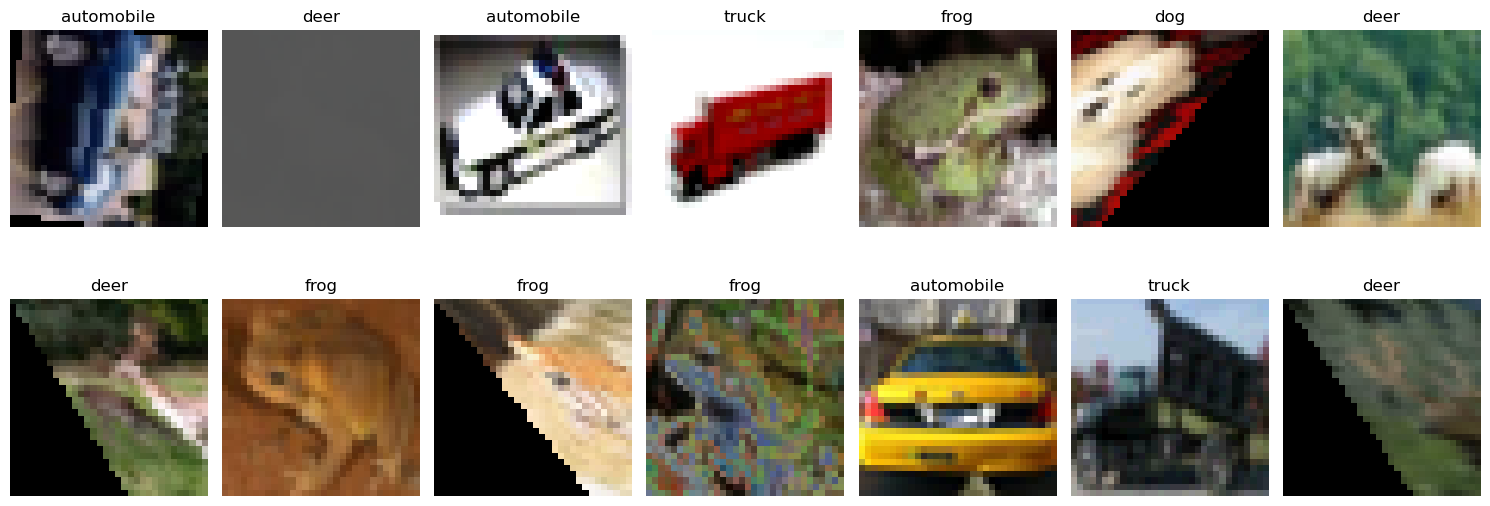

In [10]:
import matplotlib.pyplot as plt

titles = [dict_secret[y] for y in labels][0:14]
fig, axes = plt.subplots(2,7, figsize=(15, 6))
i = 0
for axs, y in zip(axes.flatten(), titles):
    axs.imshow(images[i].permute(1, 2, 0)) 
    axs.set_title(y)
    axs.axis("off")
    i+=1

plt.tight_layout()
plt.show()


### Создание базовой архитектуры CNN для классификации 

про выбор параметра out_channels - обозначает число использованных фильтров, преобразований. Полбирается основываясь на принципе уменьшить пространственной разрешение (H и W), увеличить количество каналов (C). 

In [11]:
class SimpleCNN(nn.Module):
    def __init__(self,num_classes = 5):
        super().__init__()
        # block 1
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride = 1, padding= 1)
        self.bn1 = nn.BatchNorm2d(32)
        #block 2 
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride = 2, padding= 1)
        self.bn2 = nn.BatchNorm2d(64)
        # уменьшаем изображение до 8 на 8 при помощи шага 2 
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride = 2, padding= 1)
        self.bn3 = nn.BatchNorm2d(128)

        self.fc1 = nn.Linear(128 * 8 * 8, 256) #(64x4608 and 8192x256)
        self.fc2 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self,x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)

        x = torch.flatten(x, start_dim =1)

        x = self.fc1(x)        
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x


### объявим оптимизатор и ф-ю потерь

In [12]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
model = SimpleCNN()
opt = Adam(model.parameters(), lr= 0.001)
loss_cross_entropy = nn.CrossEntropyLoss()
scheduler = ReduceLROnPlateau(opt,
                              mode = "min",
                              patience = 5,
                              factor = 0.5)

In [13]:
class EarlyStoppingSave:
    
    def __init__(self, patient = 10, delta = 0.01):
        self.patient = patient
        self.delta = delta 
        self.erly_stop = False
        self.best_loss = None
        self.counter = 0 

    def __call__(self, val_loss, train_loss, epoch, model, optimizer, scheduler, path='best_model.pth'):
        if self.best_loss == None:
            self.best_loss = val_loss

        elif self.best_loss < val_loss:
            self.counter+=1
            if self.counter >= self.patient:
                self.erly_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint( val_loss, train_loss, epoch, model, optimizer, scheduler, path)
            self.counter = 0 
    
    def save_checkpoint(self, val_loss, train_loss, epoch, model, optimizer, scheduler, path):
            """Формирует и сохраняет чекпоинт актуального состояния."""
            checkpoint = {
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
                'losses': {
                    'train_loss': train_loss,
                    'val_loss': val_loss,
                    'best_loss': self.best_loss
                },
                'epoch': epoch
            }
            torch.save(checkpoint, path)
            print(f" => Saved best model checkpoint to '{path}' (Val Loss: {val_loss:.4f})")



## Создание цикла обучения 

In [14]:
from torch.autograd import backward

dot_stop = EarlyStoppingSave()

EPOCHS = 30
loss_train_global = []
loss_val_global = []
scheduler_lr = []
for epoch in range(EPOCHS):
    loss_train = []
    loss_val = []
    model.train()
    for x, y in train_loader:
        predict = model(x)
        loss = loss_cross_entropy(predict,y)

        opt.zero_grad()
        loss.backward()
        opt.step()
        loss_train.append(loss.item())

    mean_train_loss = sum(loss_train)/len(loss_train)
    loss_train_global.append(mean_train_loss)

    model.eval()
    with torch.no_grad():
        for x,y in val_loader:
            predict = model(x)
            loss = loss_cross_entropy(predict,y)
            loss_val.append(loss.item())

    mean_val_loss = sum(loss_val)/len(loss_val)
    loss_val_global.append(mean_val_loss)

    scheduler.step(mean_val_loss)
    scheduler_lr.append(scheduler.get_last_lr()[0])

    dot_stop(mean_val_loss,
            mean_train_loss,
            epoch, model,
            opt,
            scheduler)
    
    if dot_stop.erly_stop:
        break

print(f'{epoch+1}/{EPOCHS}, train loss = {mean_train_loss:.4f}, val loss = {mean_val_loss:.4f}')
    

 => Saved best model checkpoint to 'best_model.pth' (Val Loss: 0.7852)
 => Saved best model checkpoint to 'best_model.pth' (Val Loss: 0.7538)
 => Saved best model checkpoint to 'best_model.pth' (Val Loss: 0.5963)
 => Saved best model checkpoint to 'best_model.pth' (Val Loss: 0.5437)
 => Saved best model checkpoint to 'best_model.pth' (Val Loss: 0.5126)
 => Saved best model checkpoint to 'best_model.pth' (Val Loss: 0.4761)
 => Saved best model checkpoint to 'best_model.pth' (Val Loss: 0.4501)
 => Saved best model checkpoint to 'best_model.pth' (Val Loss: 0.4102)
 => Saved best model checkpoint to 'best_model.pth' (Val Loss: 0.4079)
 => Saved best model checkpoint to 'best_model.pth' (Val Loss: 0.3992)
 => Saved best model checkpoint to 'best_model.pth' (Val Loss: 0.3857)
 => Saved best model checkpoint to 'best_model.pth' (Val Loss: 0.3629)
30/30, train loss = 0.4622, val loss = 0.3691


Посмотрим на визуализацию весов 

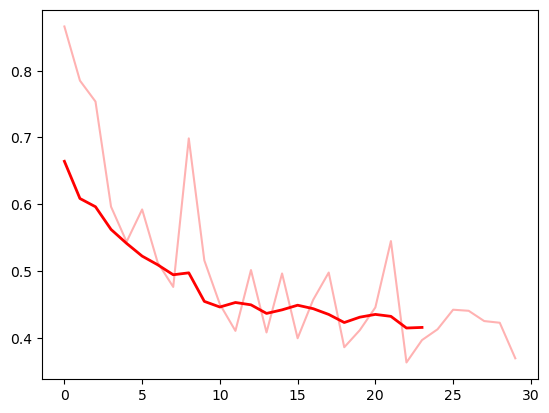

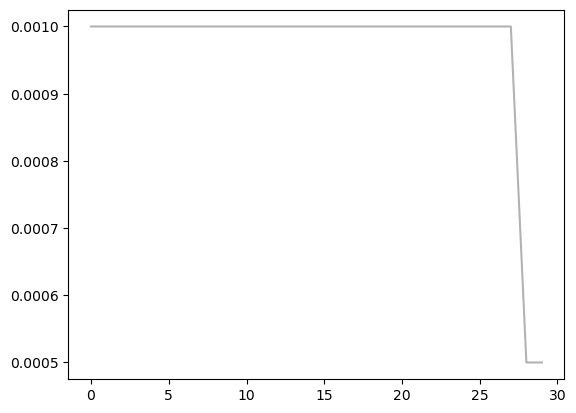

In [15]:
def smooth(values, window=5):
    return np.convolve(values, np.ones(window)/window, mode='valid')

# В цикле обучения собираю loss
# При построении графика
epochs = range(len(loss_val_global))
smooth_loss = smooth(loss_val_global, window=7)

plt.plot(epochs, loss_val_global, alpha=0.3, color='red', label='Loss (raw)')
plt.plot(range(len(smooth_loss)), smooth_loss, color='red', linewidth=2, label='Loss (smooth)')
plt.show()
plt.plot(epochs, scheduler_lr, alpha=0.3, color='black')

In [17]:
# собираем предсказания на тесте
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        preds = model(x)
        all_preds.append(preds.argmax(dim=1))
        all_labels.append(y)

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

accuracy = (all_preds == all_labels).float().mean()
print(f'Test accuracy: {accuracy:.4f}')

Test accuracy: 0.8832


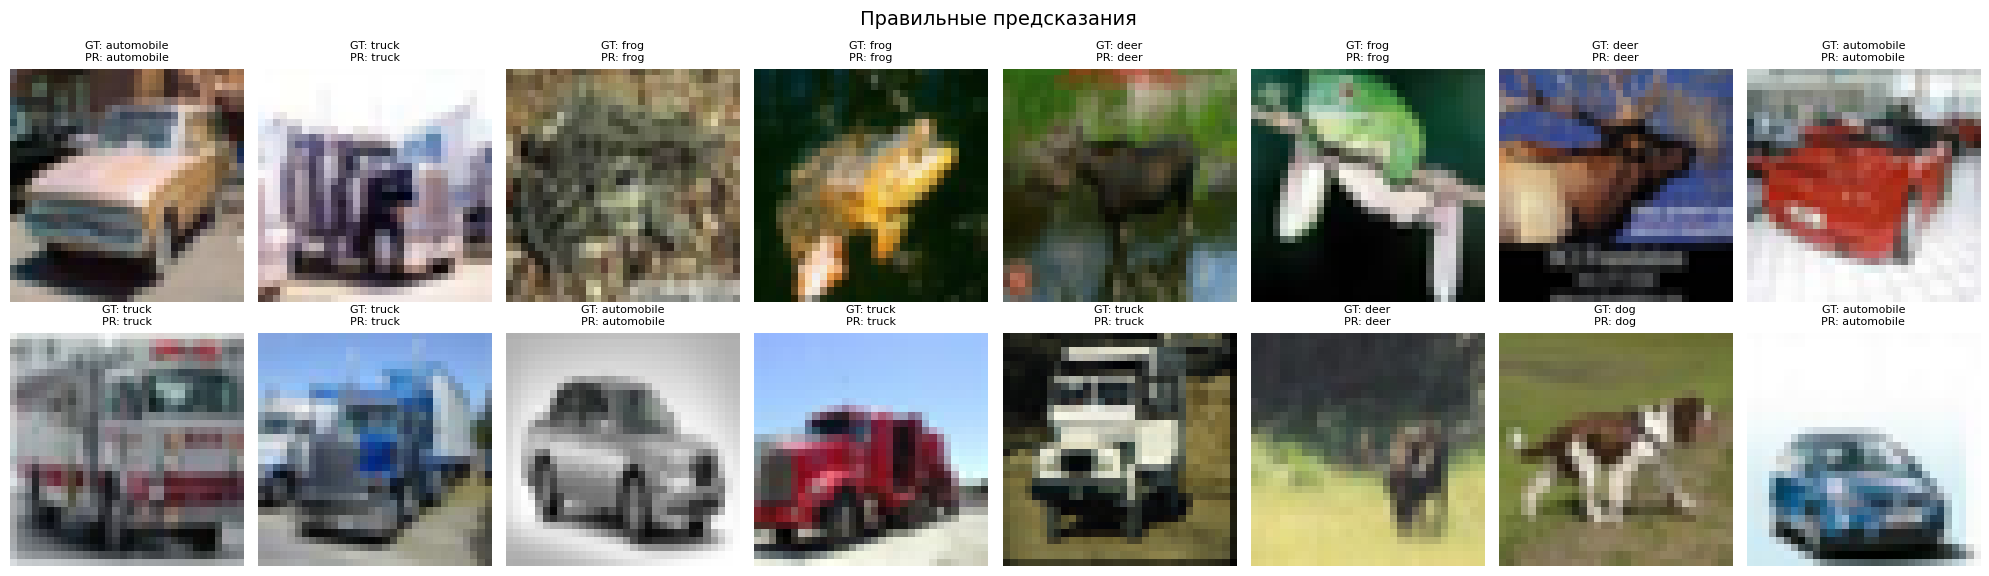

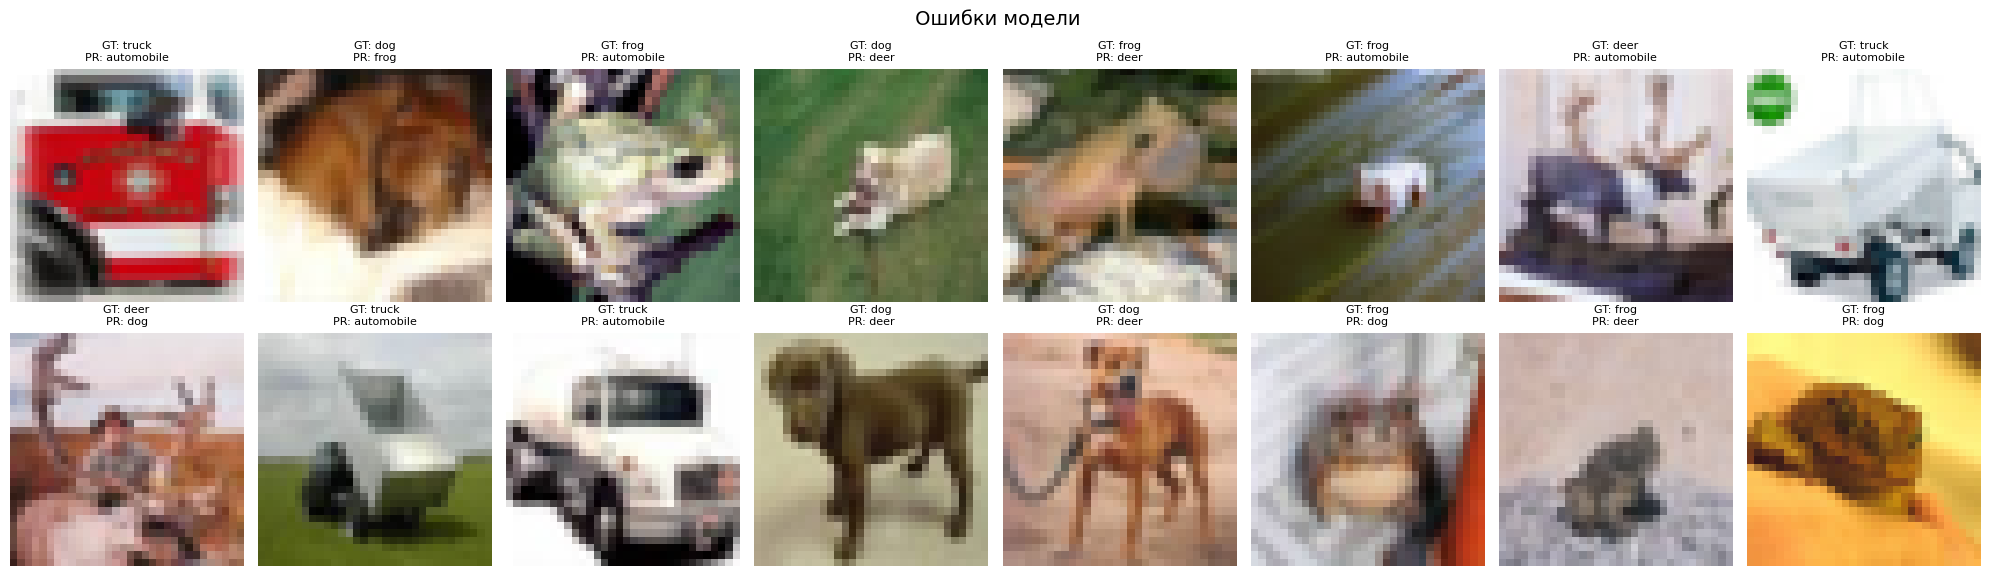

In [31]:
# находим правильные и неправильные индексы
correct_idx = (all_preds == all_labels).nonzero().squeeze()
wrong_idx = (all_preds != all_labels).nonzero().squeeze()

def show_samples( с_idx, title):

    fig, axes = plt.subplots(2, 8, figsize=(20, 6))

    for i, idx in enumerate(с_idx[:16]):
        img, label = test_l[idx.item()]
        row, col = i // 8, i % 8
        fig.suptitle(title, fontsize=14)
        axes[row, col].imshow(img.permute(1, 2, 0).clip(0, 1))
        axes[row, col].set_title(f'GT: {dict_secret[label.item()]}\n'
                                f'PR: {dict_secret[all_preds[idx].item()]}', fontsize=8)
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()


show_samples(correct_idx, ' Правильные предсказания')
show_samples(wrong_idx,   ' Ошибки модели')

В целом качество предсказаний получилось довольно хорошим с учетом, что размер обучающего датасета составил всего 15 тыс изображений , в ходе работы быдо выполнено сохранение всех наиболее важных параметров модели , так что в дальнейшем можно продолжить эксперементны над данным датасетом и взять текущую модель за некоторую отправную точку с точностью 88% на 30 эпохах.